/var/folders/rg/2bldn1q14bq6fmvnqjxkn43r0000gn/T/ipykernel_18796/54834556.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  puts_monthly["binomial_price"] = binomial_tree_batched(


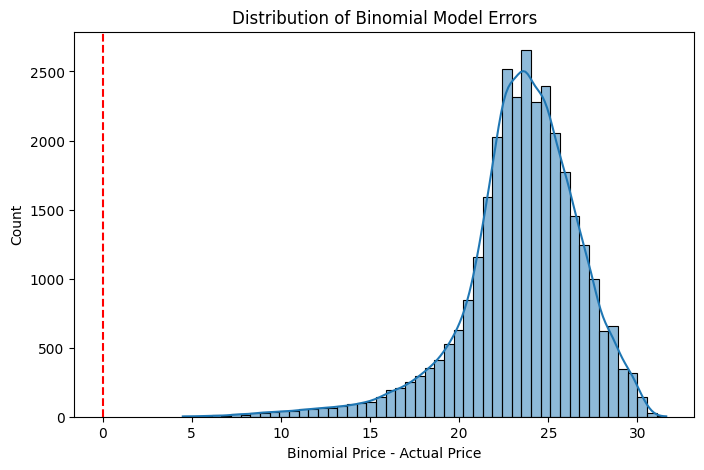

In [7]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Load parquet data
df = pd.read_parquet("data/2024_XIU.parquet")

# Define option expiration date
options_day = datetime.strptime("2024-12-31", "%Y-%m-%d")

# Calculate daily returns (assuming the 'underlying_price' column exists)
df['change_percent'] = df['underlying_price'].pct_change() * 100

# Compute annualized volatility using daily returns
annualized_volatility = df['change_percent'].std() * math.sqrt(250)  # 250 Canadian trading days

# Prepare dataframe with required parameters
df["T"] = df["dte"] / 365  # Time to maturity in years
df["sigma"] = annualized_volatility
df["r"] = 0.05  # Assuming a constant risk-free rate of 5%
df["S0"] = df["underlying_price"]
df["K"] = df["strike"]

# Filter for put options within 30-60 days to expiration
puts = df[df["option_type"] == "put"]
puts_monthly = puts[(puts["dte"] >= 30) & (puts["dte"] <= 60)]


def binomial_tree_american_put(S0, K, r, sigma, T, M):
    """
    Computes the price of an American put option using the Binomial Tree method.
    """
    dt = T / M
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)  # Risk-neutral probability
    discount = np.exp(-r * dt)

    # Stock prices at maturity
    stock_prices = np.asarray([S0 * (u ** j) * (d ** (M - j)) for j in range(M + 1)])
    option_values = np.maximum(K - stock_prices, 0)

    # Backward induction
    for t in range(M - 1, -1, -1):
        option_values = discount * (p * option_values[1:] + (1 - p) * option_values[:-1])
        stock_prices = stock_prices[:-1] / u  # Move back one step
        option_values = np.maximum(option_values, K - stock_prices)  # Check early exercise

    return option_values[0]


def binomial_tree_batched(S0, K, r, sigma, T, M=50, batch_size=1000):
    """
    Batched version of the Binomial Tree model for pricing multiple American puts.
    """
    S0 = np.atleast_1d(S0)
    K = np.atleast_1d(K)
    r = np.atleast_1d(r)
    sigma = np.atleast_1d(sigma)
    T = np.atleast_1d(T)

    L = len(S0)
    results = np.zeros(L)

    for i in range(0, L, batch_size):
        batch_end = min(i + batch_size, L)
        results[i:batch_end] = [
            binomial_tree_american_put(S0[j], K[j], r[j], sigma[j], T[j], M) for j in range(i, batch_end)
        ]

    return results


# Model Parameters
M = 50
batch_size = 1000

# Compute Binomial Tree Prices
puts_monthly["binomial_price"] = binomial_tree_batched(
    puts_monthly["S0"].values, puts_monthly["K"].values,
    puts_monthly["r"].values, puts_monthly["sigma"].values,
    puts_monthly["T"].values, M, batch_size
)

# Plot Model Errors
plt.figure(figsize=(8, 5))
sns.histplot(puts_monthly["binomial_price"] - puts_monthly["last_trade_price"], bins=50, kde=True)
plt.xlabel("Binomial Price - Actual Price")
plt.ylabel("Count")
plt.title("Distribution of Binomial Model Errors")
plt.axvline(0, color="red", linestyle="--")
plt.show()
